# Semantic Sentiment Analysis on JGH PREM — SageMaker v2.x

Performs **Spark-NLP sentiment analysis** on the redacted patient-experience data.

| | Value |
|---|---|
| **Input xlsx** | `s3://sagemaker-us-west-2-493644444178/spark-nlp/redaction/jgh-msss-prem/redacted_input/20260324_034447.xlsx` |
| **Processing script** | `sentiment_pipeline.py` |
| **Output S3** | `s3://sagemaker-us-west-2-493644444178/spark-nlp/redaction/jgh-msss-prem/redacted_output/sem_ana/` |

**Pipeline stages (inside SageMaker container)**
```
DocumentAssembler → SentenceDetector → Tokenizer → Normalizer
  → Lemmatizer → StopWordsCleaner → SentimentDetector → Finisher
  + VADER polarity UDF (compound / pos / neg / neu)
```

## 1. Environment Setup

In [1]:
import subprocess, sys, os

java_check = subprocess.run(["java", "-version"], capture_output=True)
if java_check.returncode != 0:
    print("Java not found — installing default-jdk ...")
    subprocess.run(["apt-get", "update", "-qq"], check=True)
    subprocess.run(["apt-get", "install", "-y", "-qq", "default-jdk"], check=True)
    print("Java installed.")
else:
    print("Java already available:", java_check.stderr.decode().split('\n')[0])

java_home_candidates = [
    "/usr/lib/jvm/java-11-openjdk-amd64",
    "/usr/lib/jvm/java-11-amazon-corretto",
    "/usr/lib/jvm/java-8-openjdk-amd64",
    "/usr/lib/jvm/java-8-amazon-corretto",
]
for candidate in java_home_candidates:
    if os.path.isdir(candidate):
        os.environ["JAVA_HOME"] = candidate
        break
else:
    result = subprocess.run(
        ["java", "-XshowSettings:all", "-version"],
        capture_output=True, text=True
    )
    for line in result.stderr.splitlines():
        if "java.home" in line:
            java_home = line.split("=")[1].strip()
            if java_home.endswith("/jre"):
                java_home = java_home[:-4]
            os.environ["JAVA_HOME"] = java_home
            break

print("JAVA_HOME:", os.environ.get("JAVA_HOME", "NOT SET"))

Java already available: openjdk version "11.0.30" 2026-01-20
JAVA_HOME: /usr/lib/jvm/java-11-openjdk-amd64


In [2]:
!pip install -q \
    "sagemaker>=2.0,<3.0" \
    "pyspark>=3.3,<3.6" \
    "boto3" \
    "nltk" \
    "openpyxl" \
    "wordcloud" \
    "matplotlib" \
    "seaborn" \
    "pandas<2.0" \
    "pyarrow"

print("All packages installed.")

All packages installed.


## 2. SageMaker v2.x Session Setup

In [3]:
import boto3
import sagemaker
from sagemaker import get_execution_role

boto_session = boto3.Session()
sm_session   = sagemaker.Session(boto_session=boto_session)

try:
    role = get_execution_role(sagemaker_session=sm_session)
except Exception:
    role = os.environ.get("SAGEMAKER_ROLE", "<YOUR_SAGEMAKER_EXECUTION_ROLE_ARN>")
    print("WARNING: Could not auto-detect execution role. Set SAGEMAKER_ROLE env var.")

region  = boto_session.region_name or sm_session.boto_region_name
account = boto3.client("sts").get_caller_identity()["Account"]

BUCKET         = "sagemaker-us-west-2-493644444178"
INPUT_XLSX_S3  = f"s3://{BUCKET}/spark-nlp/redaction/jgh-msss-prem/redacted_input/20260324_034447.xlsx"
# New clean prefix — avoids the bad object uploaded by the previous run
PARQUET_S3     = f"s3://{BUCKET}/spark-nlp/redaction/jgh-msss-prem/redacted_input/20260324_034447_input/"
SEM_OUTPUT_S3  = f"s3://{BUCKET}/spark-nlp/redaction/jgh-msss-prem/redacted_output/sem_ana/"

print(f"SageMaker SDK version : {sagemaker.__version__}")
print(f"Region                : {region}")
print(f"Account               : {account}")
print(f"Execution role ARN    : {role}")
print(f"Input  xlsx S3        : {INPUT_XLSX_S3}")
print(f"Parquet input S3      : {PARQUET_S3}")
print(f"Output S3             : {SEM_OUTPUT_S3}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/cjen/.config/sagemaker/config.yaml
SageMaker SDK version : 2.253.1
Region                : us-west-2
Account               : 493644444178
Execution role ARN    : arn:aws:iam::493644444178:role/aws-reserved/sso.amazonaws.com/ap-southeast-1/AWSReservedSSO_AWSAdministratorAccess_e93147afb9349dfd
Input  xlsx S3        : s3://sagemaker-us-west-2-493644444178/spark-nlp/redaction/jgh-msss-prem/redacted_input/20260324_034447.xlsx
Parquet input S3      : s3://sagemaker-us-west-2-493644444178/spark-nlp/redaction/jgh-msss-prem/redacted_input/20260324_034447_input/
Output S3             : s3://sagemaker-us-west-2-493644444178/spark-nlp/redaction/jgh-msss-prem/redacted_output/sem_ana/


## 3. Import Libraries

In [4]:
import json, os, re, math, random, time, warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
sns.set_style("darkgrid")

from wordcloud import WordCloud, STOPWORDS

# Plain PySpark — Spark-NLP runs only inside SageMaker Processing Job containers
from pyspark.sql import SparkSession, Row
from pyspark.sql import types as T
from pyspark.sql import functions as F
from pyspark.sql.functions import (
    udf, col, size, trim, when, concat_ws, explode,
    monotonically_increasing_id,
)

warnings.filterwarnings("ignore")
pd.options.display.max_colwidth = None
pd.options.display.float_format = "${:,.3f}".format

colors = sns.color_palette("PuBuGn")
print("Libraries imported.")

Libraries imported.


## 4. Start Local PySpark Session

Plain PySpark only — **Spark-NLP is not started locally**.  
It runs exclusively inside the SageMaker Processing Job container.

In [5]:
spark = (
    SparkSession.builder
    .appName("SemAna-Sentiment")
    .config("spark.driver.memory", "16G")
    .config("spark.driver.maxResultSize", "2000M")
    .getOrCreate()
)
spark

26/03/30 16:22:32 WARN Utils: Your hostname, MindyJen1008 resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/03/30 16:22:32 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/30 16:22:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 5. Configure Text Columns

Both free-text columns are passed as a comma-separated argument to `sentiment_pipeline.py` inside the SageMaker container, which runs the pipeline on each and stores prefixed output columns (e.g. `aspects_text_vader_label`, `suggestions_text_sentiment_label`, …).

In [6]:
# Columns that contain free-text patient feedback.
# Both are analysed in the same SageMaker Processing Job run.
TEXT_COLS = ["aspects_text", "suggestions_text"]

print(f"Active text columns : {TEXT_COLS}")

Active text columns : ['aspects_text', 'suggestions_text']


## 6. Pre-process Input: xlsx → Parquet

Spark cannot read `.xlsx` natively.  
Download the file from S3, convert via pandas/pyarrow, and re-upload as parquet.

In [7]:
import io

LOCAL_XLSX = "/tmp/input_data.xlsx"
xlsx_key   = INPUT_XLSX_S3.replace(f"s3://{BUCKET}/", "")

s3_client = boto3.client("s3", region_name=region)
print(f"Downloading s3://{BUCKET}/{xlsx_key} ...")
s3_client.download_file(BUCKET, xlsx_key, LOCAL_XLSX)
print(f"  Saved to {LOCAL_XLSX}  ({os.path.getsize(LOCAL_XLSX):,} bytes)")

xlsx_df = pd.read_excel(LOCAL_XLSX, engine="openpyxl")
print(f"\nDataFrame shape : {xlsx_df.shape}")
print(f"Columns         : {list(xlsx_df.columns)}")
xlsx_df.head(3)

  Saved to /tmp/input_data.xlsx  (562,510 bytes)

DataFrame shape : (6761, 5)
Columns         : ['Unnamed: 0', ' Date de complétion', 'Évaluation', "Aspects positifs de l'expérience globale ", "Suggestions d'amélioration de l'expérience globale "]


,Unnamed: 0,Date de complétion,Évaluation,Aspects positifs de l'expérience globale,Suggestions d'amélioration de l'expérience globale
0,0,2024-11-14 02:32:11.142000+00:00,NaN,pris en mains rapidement et efficacement à l'arrivée à l'urgence,NaN
1,1,2025-09-13 11:41:05.701000+00:00,NaN,The doctor did a thorough review and told us what could be done.,NaN
2,2,2024-09-10 19:00:44.604000+00:00,NaN,soins adéquats.,NaN


In [8]:
import shutil

LOCAL_PARQUET = "/tmp/input_parquet"
if os.path.exists(LOCAL_PARQUET):
    shutil.rmtree(LOCAL_PARQUET)
os.makedirs(LOCAL_PARQUET, exist_ok=True)

# Rename French column headers → clean ASCII names
xlsx_df = xlsx_df.rename(columns={
    "Unnamed: 0"                                           : "row_id",
    " Date de complétion"                                  : "completion_date",
    "Évaluation"                                           : "evaluation",
    "Aspects positifs de l'expérience globale "            : "aspects_text",
    "Suggestions d'amélioration de l'expérience globale "  : "suggestions_text",
})
print(f"Renamed columns: {list(xlsx_df.columns)}")

# Coerce all object columns to string to avoid pyarrow type errors
for c in xlsx_df.select_dtypes(include="object").columns:
    xlsx_df[c] = xlsx_df[c].where(xlsx_df[c].notna(), None).astype(str)

parquet_file = f"{LOCAL_PARQUET}/part-00000.parquet"
xlsx_df.to_parquet(parquet_file, index=False, engine="pyarrow")
print(f"Written parquet: {parquet_file}  ({os.path.getsize(parquet_file):,} bytes)")

# Upload with boto3 directly to control the exact S3 key (no double-slash risk)
parquet_key = (
    "spark-nlp/redaction/jgh-msss-prem/redacted_input"
    "/20260324_034447_input/part-00000.parquet"
)
s3_client.upload_file(parquet_file, BUCKET, parquet_key)
print(f"Staged at: s3://{BUCKET}/{parquet_key}")

Renamed columns: ['row_id', 'completion_date', 'evaluation', 'aspects_text', 'suggestions_text']
Written parquet: /tmp/input_parquet/part-00000.parquet  (717,900 bytes)
Staged at: s3://sagemaker-us-west-2-493644444178/spark-nlp/redaction/jgh-msss-prem/redacted_input/20260324_034447_input/part-00000.parquet


## 7. Resolve SageMaker-Assumable IAM Role

In [9]:
import boto3, json, time

iam          = boto3.client("iam")
SM_ROLE_NAME = "SageMakerExecutionRole-SparkNLP"

TRUST_POLICY = json.dumps({
    "Version": "2012-10-17",
    "Statement": [{
        "Effect"   : "Allow",
        "Principal": {"Service": "sagemaker.amazonaws.com"},
        "Action"   : "sts:AssumeRole",
    }],
})

try:
    sm_role = iam.get_role(RoleName=SM_ROLE_NAME)["Role"]["Arn"]
    print(f"Reusing existing role: {sm_role}")
except iam.exceptions.NoSuchEntityException:
    print(f"Creating '{SM_ROLE_NAME}' ...")
    sm_role = iam.create_role(
        RoleName                 = SM_ROLE_NAME,
        AssumeRolePolicyDocument = TRUST_POLICY,
        Description              = "SageMaker execution role for Spark-NLP processing jobs",
    )["Role"]["Arn"]
    for policy_arn in [
        "arn:aws:iam::aws:policy/AmazonSageMakerFullAccess",
        "arn:aws:iam::aws:policy/AmazonS3FullAccess",
    ]:
        iam.attach_role_policy(RoleName=SM_ROLE_NAME, PolicyArn=policy_arn)
        print(f"  Attached {policy_arn}")
    print("Waiting 15 s for IAM propagation ...")
    time.sleep(15)

print(f"\nsm_role = {sm_role}")

Reusing existing role: arn:aws:iam::493644444178:role/SageMakerExecutionRole-SparkNLP

sm_role = arn:aws:iam::493644444178:role/SageMakerExecutionRole-SparkNLP


## 8. Stage Spark-NLP Assembly JAR

In [10]:
import urllib.request
from sagemaker.s3 import S3Uploader

NLP_VER         = "5.5.3"
jar_name        = f"spark-nlp-assembly-{NLP_VER}.jar"
jar_prefix      = "spark-nlp/key-ana"   # reuse JAR already staged by lem / top jobs
sparknlp_jar_s3 = f"s3://{BUCKET}/{jar_prefix}/jars/{jar_name}"

s3_client = boto3.client("s3")
jar_key   = f"{jar_prefix}/jars/{jar_name}"
try:
    s3_client.head_object(Bucket=BUCKET, Key=jar_key)
    print(f"JAR already staged: {sparknlp_jar_s3}")
except s3_client.exceptions.ClientError:
    print("JAR not found — downloading and staging ...")
    local = f"/tmp/{jar_name}"
    for url in [
        f"https://s3.amazonaws.com/auxdata.johnsnowlabs.com/public/jars/{jar_name}",
        f"https://repo1.maven.org/maven2/com/johnsnowlabs/nlp/spark-nlp-assembly_2.12/{NLP_VER}/spark-nlp-assembly_2.12-{NLP_VER}.jar",
    ]:
        try:
            print(f"  Trying {url}")
            urllib.request.urlretrieve(url, local)
            with open(local, "rb") as f:
                if f.read(2) != b"PK":
                    raise RuntimeError("Not a valid JAR")
            S3Uploader.upload(local, f"s3://{BUCKET}/{jar_prefix}/jars", sagemaker_session=sm_session)
            print(f"  Staged at {sparknlp_jar_s3}")
            break
        except Exception as e:
            print(f"  x {e}")
    else:
        raise RuntimeError("Could not obtain the Spark-NLP assembly JAR.")

print(f"\nsparknlp_jar_s3 = {sparknlp_jar_s3}")

JAR already staged: s3://sagemaker-us-west-2-493644444178/spark-nlp/key-ana/jars/spark-nlp-assembly-5.5.3.jar

sparknlp_jar_s3 = s3://sagemaker-us-west-2-493644444178/spark-nlp/key-ana/jars/spark-nlp-assembly-5.5.3.jar


## 9. Submit `sentiment_pipeline.py` Processing Job

`PySparkProcessor` provisions `ml.m5.4xlarge`, runs `sentiment_pipeline.py` inside
the managed Spark-NLP container, and **automatically terminates** when done.

The Spark-NLP workflow inside the container:
```
DocumentAssembler → SentenceDetector → Tokenizer → Normalizer
  → Lemmatizer → StopWordsCleaner → SentimentDetector → Finisher
  + VADER polarity UDF
```

In [11]:
from sagemaker.spark.processing import PySparkProcessor
from sagemaker.processing import ProcessingInput, ProcessingOutput

SPARK_CONFIG = [{
    "Classification": "spark-defaults",
    "Properties": {
        "spark.serializer"                : "org.apache.spark.serializer.KryoSerializer",
        "spark.kryoserializer.buffer.max" : "2000M",
        "spark.driver.memory"             : "16G",
        "spark.driver.maxResultSize"      : "4000M",
        "spark.executor.memory"           : "20G",
        "spark.executor.memoryOverhead"   : "4G",
    },
}]

sem_processor = PySparkProcessor(
    base_job_name          = "spark-nlp-sentiment-pipeline",
    framework_version      = "3.3",
    role                   = sm_role,
    instance_count         = 1,
    instance_type          = "ml.m5.4xlarge",
    max_runtime_in_seconds = 3600,
    sagemaker_session      = sm_session,
)

# Pass both text columns as a comma-separated string; sentiment_pipeline.py splits on ","
sem_processor.run(
    submit_app    = "sentiment_pipeline.py",
    submit_jars   = [sparknlp_jar_s3],
    arguments     = [",".join(TEXT_COLS)],
    configuration = SPARK_CONFIG,
    inputs  = [ProcessingInput(
        source      = PARQUET_S3,
        destination = "/opt/ml/processing/input",
    )],
    outputs = [ProcessingOutput(
        source      = "/opt/ml/processing/output/data",
        destination = SEM_OUTPUT_S3,
    )],
    logs = True,
    wait = True,
)

print(f"\nSentiment pipeline job complete. Output: {SEM_OUTPUT_S3}")

INFO:sagemaker:Creating processing-job with name spark-nlp-sentiment-pipeline-2026-03-30-23-22-37-966


............03-30 23:24 smspark.cli  INFO     Parsing arguments. argv: ['/usr/local/bin/smspark-submit', '--jars', 's3://sagemaker-us-west-2-493644444178/spark-nlp/key-ana/jars/spark-nlp-assembly-5.5.3.jar', '/opt/ml/processing/input/code/sentiment_pipeline.py', 'aspects_text,suggestions_text']
03-30 23:24 smspark.cli  INFO     Raw spark options before processing: {'jars': 's3://sagemaker-us-west-2-493644444178/spark-nlp/key-ana/jars/spark-nlp-assembly-5.5.3.jar', 'class_': None, 'py_files': None, 'files': None, 'verbose': False}
03-30 23:24 smspark.cli  INFO     App and app arguments: ['/opt/ml/processing/input/code/sentiment_pipeline.py', 'aspects_text,suggestions_text']
03-30 23:24 smspark.cli  INFO     Rendered spark options: {'jars': 's3://sagemaker-us-west-2-493644444178/spark-nlp/key-ana/jars/spark-nlp-assembly-5.5.3.jar', 'class_': None, 'py_files': None, 'files': None, 'verbose': False}
03-30 23:24 smspark.cli  INFO     Initializing processing job.
03-30 23:24 smspark-submit I

### 9.1 Fetch CloudWatch Logs

In [12]:
logs      = boto3.client("logs", region_name=region)
job_name  = sem_processor.latest_job.job_name
log_group = "/aws/sagemaker/ProcessingJobs"
print(f"Job      : {job_name}")
print(f"LogGroup : {log_group}\n")

for attempt in range(10):
    resp    = logs.describe_log_streams(logGroupName=log_group, logStreamNamePrefix=job_name)
    streams = resp.get("logStreams", [])
    if streams:
        break
    print(f"  Waiting for log streams (attempt {attempt+1}/10) ...")
    time.sleep(6)

for stream in streams:
    print(f"\n{'='*60}\nStream: {stream['logStreamName']}\n{'='*60}")
    for event in logs.get_log_events(
        logGroupName=log_group,
        logStreamName=stream["logStreamName"],
        startFromHead=True,
    )["events"]:
        print(event["message"])

Job      : spark-nlp-sentiment-pipeline-2026-03-30-23-22-37-966
LogGroup : /aws/sagemaker/ProcessingJobs


Stream: spark-nlp-sentiment-pipeline-2026-03-30-23-22-37-966/algo-1-1774912996
03-30 23:24 smspark.cli  INFO     Parsing arguments. argv: ['/usr/local/bin/smspark-submit', '--jars', 's3://sagemaker-us-west-2-493644444178/spark-nlp/key-ana/jars/spark-nlp-assembly-5.5.3.jar', '/opt/ml/processing/input/code/sentiment_pipeline.py', 'aspects_text,suggestions_text']
03-30 23:24 smspark.cli  INFO     Raw spark options before processing: {'jars': 's3://sagemaker-us-west-2-493644444178/spark-nlp/key-ana/jars/spark-nlp-assembly-5.5.3.jar', 'class_': None, 'py_files': None, 'files': None, 'verbose': False}
03-30 23:24 smspark.cli  INFO     App and app arguments: ['/opt/ml/processing/input/code/sentiment_pipeline.py', 'aspects_text,suggestions_text']
03-30 23:24 smspark.cli  INFO     Rendered spark options: {'jars': 's3://sagemaker-us-west-2-493644444178/spark-nlp/key-ana/jars/spark-nlp-assem

## 10. Download Output & Load into Local Spark

Download the output parquet from S3 and load it into the local PySpark session
for exploration and visualisation.

In [13]:
LOCAL_SEM_DIR = "/tmp/sem_ana_output"
if os.path.exists(LOCAL_SEM_DIR):
    shutil.rmtree(LOCAL_SEM_DIR)
os.makedirs(LOCAL_SEM_DIR, exist_ok=True)

sem_prefix = SEM_OUTPUT_S3.replace(f"s3://{BUCKET}/", "").rstrip("/") + "/"
paginator  = boto3.client("s3").get_paginator("list_objects_v2")
sem_files  = [
    obj["Key"]
    for page in paginator.paginate(Bucket=BUCKET, Prefix=sem_prefix)
    for obj in page.get("Contents", [])
    if obj["Key"].endswith(".parquet")
]
print(f"Parquet files in sem_ana output: {len(sem_files)}")
for k in sem_files:
    print(f"  s3://{BUCKET}/{k}")

s3_dl = boto3.client("s3", region_name=region)
for key in sem_files:
    fname = os.path.basename(key)
    dest  = os.path.join(LOCAL_SEM_DIR, fname)
    s3_dl.download_file(BUCKET, key, dest)
    print(f"  Downloaded {fname}")

result_df = spark.read.parquet(f"file://{LOCAL_SEM_DIR}")
print(f"\nLoaded : {result_df.count()} rows,  columns: {result_df.columns}")

Parquet files in sem_ana output: 1
  s3://sagemaker-us-west-2-493644444178/spark-nlp/redaction/jgh-msss-prem/redacted_output/sem_ana/part-00000-39745f1c-5dc3-4b86-80cb-68c8746f723f-c000.snappy.parquet
  Downloaded part-00000-39745f1c-5dc3-4b86-80cb-68c8746f723f-c000.snappy.parquet



Loaded : 6760 rows,  columns: ['row_id', 'completion_date', 'evaluation', 'aspects_text', 'suggestions_text', 'aspects_text_finished_sentiment', 'aspects_text_finished_tokens', 'aspects_text_sentiment_label', 'aspects_text_vader_compound', 'aspects_text_vader_pos', 'aspects_text_vader_neg', 'aspects_text_vader_neu', 'aspects_text_vader_label', 'suggestions_text_finished_sentiment', 'suggestions_text_finished_tokens', 'suggestions_text_sentiment_label', 'suggestions_text_vader_compound', 'suggestions_text_vader_pos', 'suggestions_text_vader_neg', 'suggestions_text_vader_neu', 'suggestions_text_vader_label']


## 11. Explore Results

In [14]:
result_df.printSchema()

for tc in TEXT_COLS:
    print(f"\n{'='*60}\nColumn: {tc}\n{'='*60}")
    result_df.select(
        tc,
        f"{tc}_sentiment_label",
        f"{tc}_vader_label",
        f"{tc}_vader_compound",
        f"{tc}_vader_pos",
        f"{tc}_vader_neg",
        f"{tc}_vader_neu",
        f"{tc}_finished_tokens",
    ).show(10, truncate=100)

root
 |-- row_id: long (nullable = true)
 |-- completion_date: string (nullable = true)
 |-- evaluation: double (nullable = true)
 |-- aspects_text: string (nullable = true)
 |-- suggestions_text: string (nullable = true)
 |-- aspects_text_finished_sentiment: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- aspects_text_finished_tokens: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- aspects_text_sentiment_label: string (nullable = true)
 |-- aspects_text_vader_compound: double (nullable = true)
 |-- aspects_text_vader_pos: double (nullable = true)
 |-- aspects_text_vader_neg: double (nullable = true)
 |-- aspects_text_vader_neu: double (nullable = true)
 |-- aspects_text_vader_label: string (nullable = true)
 |-- suggestions_text_finished_sentiment: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- suggestions_text_finished_tokens: array (nullable = true)
 |    |-- element: string (containsNull = true)

In [15]:
for tc in TEXT_COLS:
    print(f"\n{'='*60}")
    print(f"=== [{tc}] Spark-NLP SentimentDetector labels ===")
    result_df.groupBy(f"{tc}_sentiment_label").count().orderBy(col("count").desc()).show()

    print(f"=== [{tc}] VADER labels ===")
    result_df.groupBy(f"{tc}_vader_label").count().orderBy(col("count").desc()).show()


=== [aspects_text] Spark-NLP SentimentDetector labels ===
+----------------------------+-----+
|aspects_text_sentiment_label|count|
+----------------------------+-----+
|                    positive| 6721|
|                    negative|   39|
+----------------------------+-----+

=== [aspects_text] VADER labels ===
+------------------------+-----+
|aspects_text_vader_label|count|
+------------------------+-----+
|                 neutral| 4265|
|                positive| 2127|
|                negative|  368|
+------------------------+-----+


=== [suggestions_text] Spark-NLP SentimentDetector labels ===
+--------------------------------+-----+
|suggestions_text_sentiment_label|count|
+--------------------------------+-----+
|                        positive| 6720|
|                        negative|   40|
+--------------------------------+-----+

=== [suggestions_text] VADER labels ===
+----------------------------+-----+
|suggestions_text_vader_label|count|
+-------------------------

## 12. Visualization

### 12.1 Sentiment Distribution Bar Charts

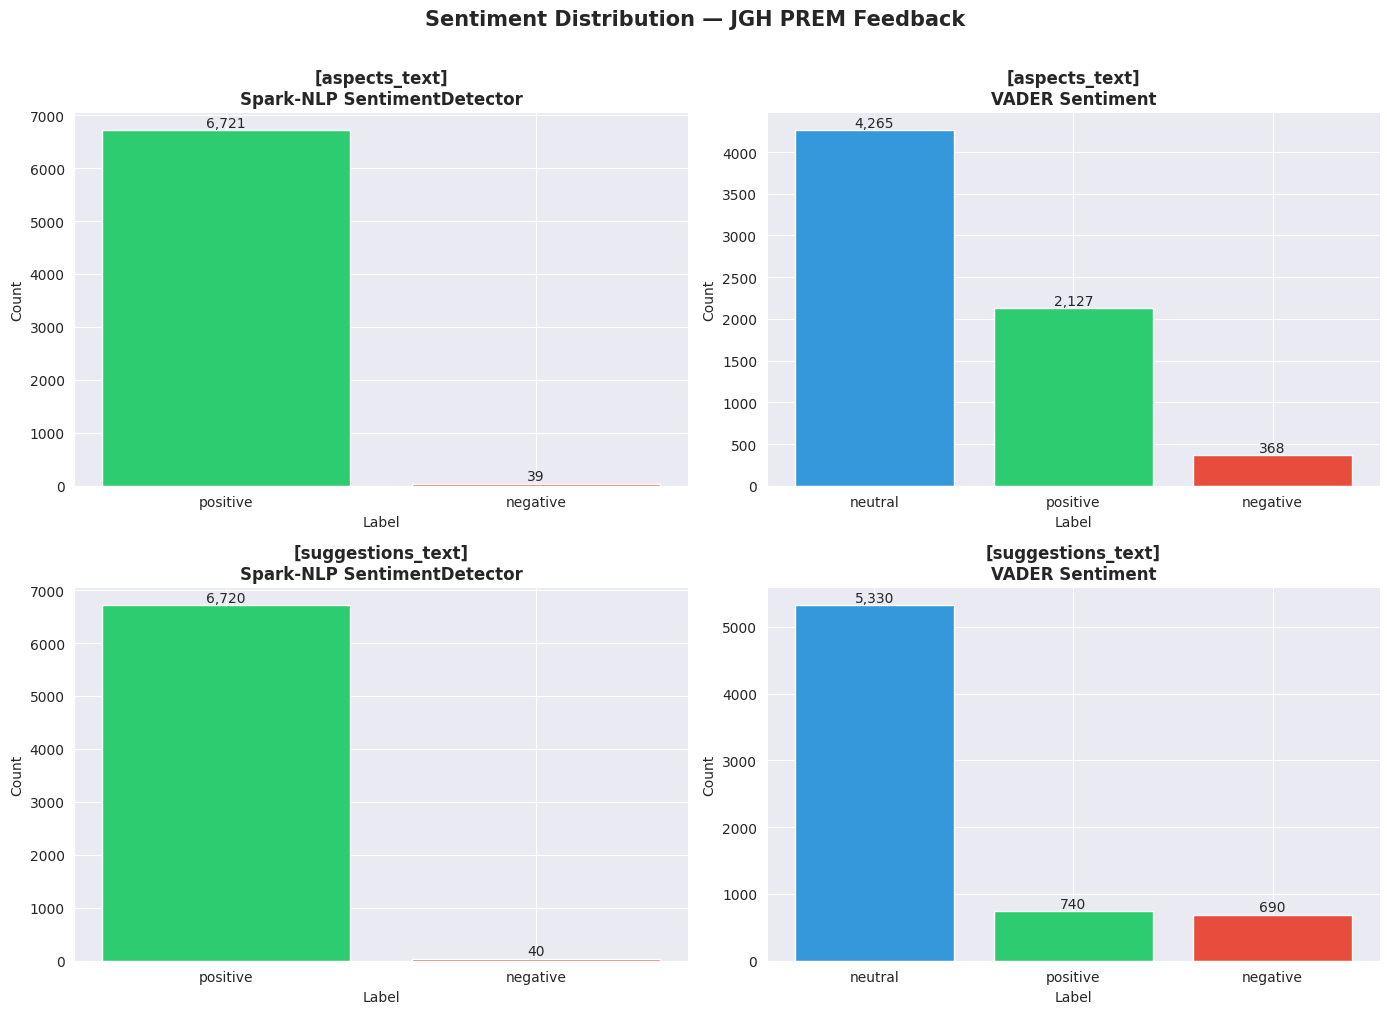

In [16]:
palette_spark = {"positive": "#2ecc71", "negative": "#e74c3c", "na": "#95a5a6"}
palette_vader = {"positive": "#2ecc71", "negative": "#e74c3c", "neutral": "#3498db"}

fig, axes = plt.subplots(len(TEXT_COLS), 2, figsize=(14, 5 * len(TEXT_COLS)))
if len(TEXT_COLS) == 1:
    axes = [axes]   # make it always 2-D

for row_idx, tc in enumerate(TEXT_COLS):
    spark_counts = (
        result_df.groupBy(f"{tc}_sentiment_label").count()
        .toPandas().sort_values("count", ascending=False)
        .rename(columns={f"{tc}_sentiment_label": "label"})
    )
    vader_counts = (
        result_df.groupBy(f"{tc}_vader_label").count()
        .toPandas().sort_values("count", ascending=False)
        .rename(columns={f"{tc}_vader_label": "label"})
    )

    ax0, ax1 = axes[row_idx]

    ax0.bar(
        spark_counts["label"], spark_counts["count"],
        color=[palette_spark.get(l, "#bdc3c7") for l in spark_counts["label"]],
    )
    ax0.set_title(f"[{tc}]\nSpark-NLP SentimentDetector", fontsize=12, fontweight="bold")
    ax0.set_xlabel("Label"); ax0.set_ylabel("Count")
    for bar in ax0.patches:
        ax0.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=10)

    ax1.bar(
        vader_counts["label"], vader_counts["count"],
        color=[palette_vader.get(l, "#bdc3c7") for l in vader_counts["label"]],
    )
    ax1.set_title(f"[{tc}]\nVADER Sentiment", fontsize=12, fontweight="bold")
    ax1.set_xlabel("Label"); ax1.set_ylabel("Count")
    for bar in ax1.patches:
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=10)

plt.suptitle("Sentiment Distribution — JGH PREM Feedback", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 12.2 VADER Compound Score Distribution

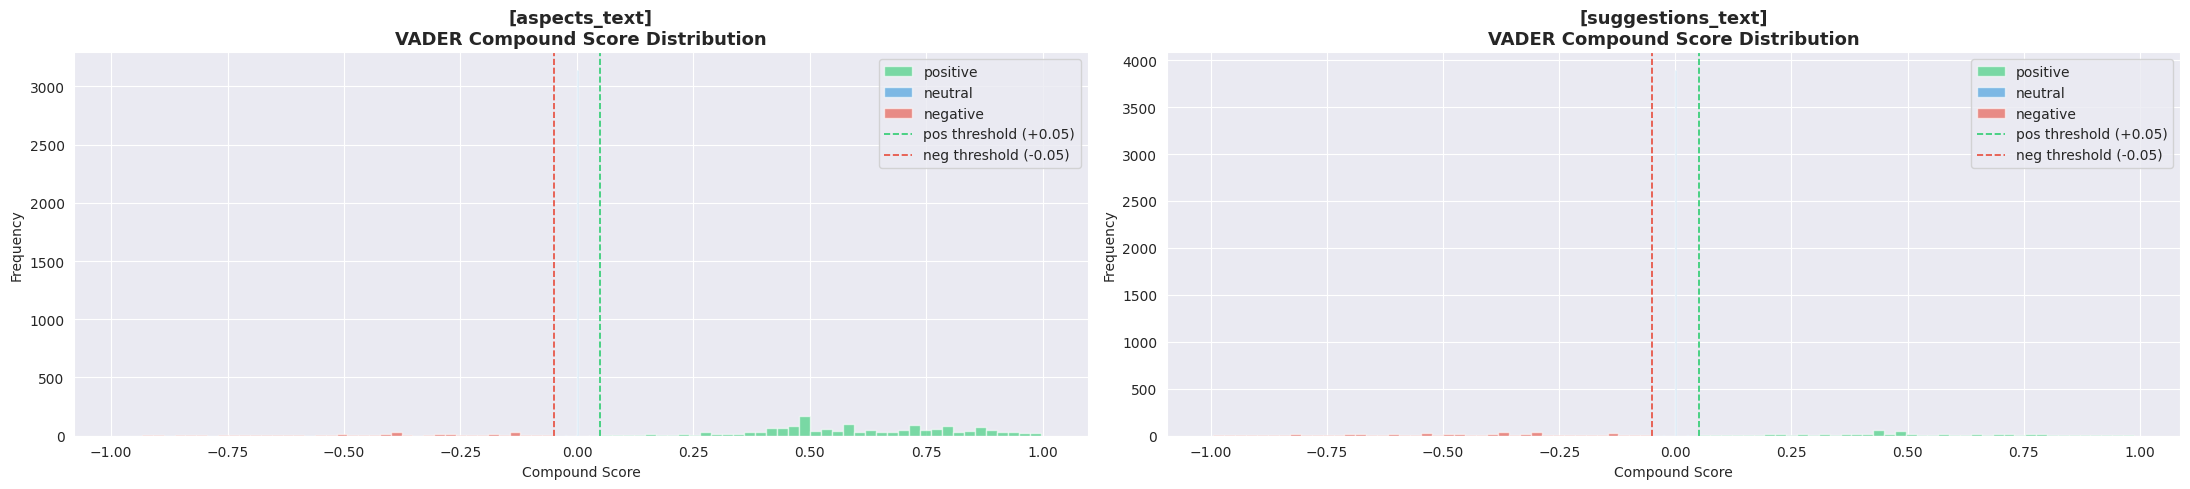

In [17]:
fig, axes = plt.subplots(1, len(TEXT_COLS), figsize=(11 * len(TEXT_COLS), 5))
if len(TEXT_COLS) == 1:
    axes = [axes]

for ax, tc in zip(axes, TEXT_COLS):
    compound_pdf = (
        result_df
        .select(f"{tc}_vader_compound", f"{tc}_vader_label")
        .limit(5000).toPandas()
        .rename(columns={f"{tc}_vader_compound": "vader_compound", f"{tc}_vader_label": "vader_label"})
    )
    for label, color in [("positive", "#2ecc71"), ("neutral", "#3498db"), ("negative", "#e74c3c")]:
        subset = compound_pdf[compound_pdf["vader_label"] == label]["vader_compound"]
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=label, edgecolor="white")

    ax.axvline( 0.05, color="#2ecc71", linestyle="--", linewidth=1.2, label="pos threshold (+0.05)")
    ax.axvline(-0.05, color="#e74c3c", linestyle="--", linewidth=1.2, label="neg threshold (-0.05)")
    ax.set_title(f"[{tc}]\nVADER Compound Score Distribution", fontsize=13, fontweight="bold")
    ax.set_xlabel("Compound Score"); ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.show()

### 12.3 Word Cloud by Sentiment (VADER)

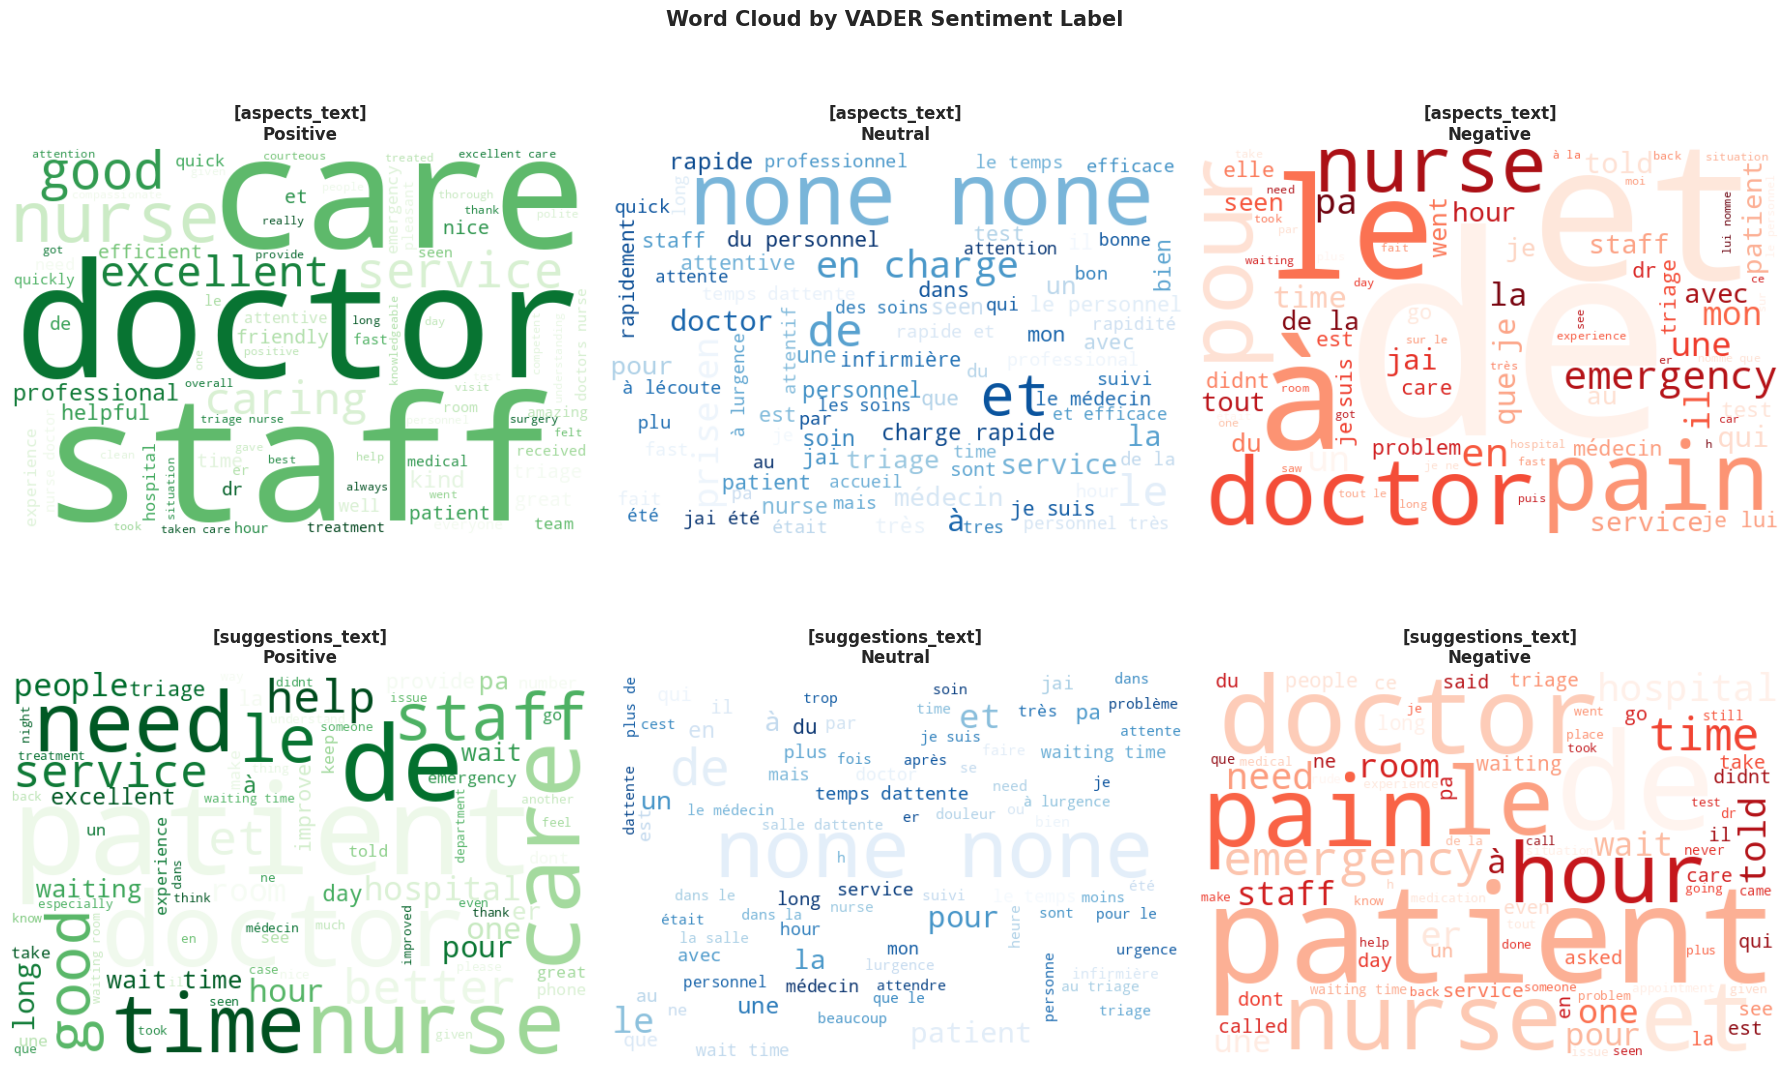

In [18]:
def tokens_for_label(df, tc, label):
    subset = (
        df.filter(col(f"{tc}_vader_label") == label)
          .select(f"{tc}_finished_tokens")
          .limit(3000).toPandas()
    )
    words = []
    for row in subset[f"{tc}_finished_tokens"]:
        if row:
            words.extend(row)
    return " ".join(words)

label_colors = {"positive": "Greens", "neutral": "Blues", "negative": "Reds"}
labels       = ["positive", "neutral", "negative"]

fig, axes = plt.subplots(len(TEXT_COLS), 3,
                         figsize=(18, 6 * len(TEXT_COLS)))
if len(TEXT_COLS) == 1:
    axes = [axes]

for row_idx, tc in enumerate(TEXT_COLS):
    for col_idx, label in enumerate(labels):
        ax   = axes[row_idx][col_idx]
        text = tokens_for_label(result_df, tc, label)
        if not text.strip():
            ax.set_title(f"[{tc}]\n{label.capitalize()} (no data)")
            ax.axis("off")
            continue
        wc = WordCloud(
            width=600, height=400,
            background_color="white",
            colormap=label_colors[label],
            max_words=80, stopwords=STOPWORDS,
        ).generate(text)
        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(f"[{tc}]\n{label.capitalize()}", fontsize=12, fontweight="bold")
        ax.axis("off")

plt.suptitle("Word Cloud by VADER Sentiment Label", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### 12.4 Spark-NLP vs VADER Agreement Cross-tab

Shows how the rule-based `SentimentDetector` labels align with VADER scores.

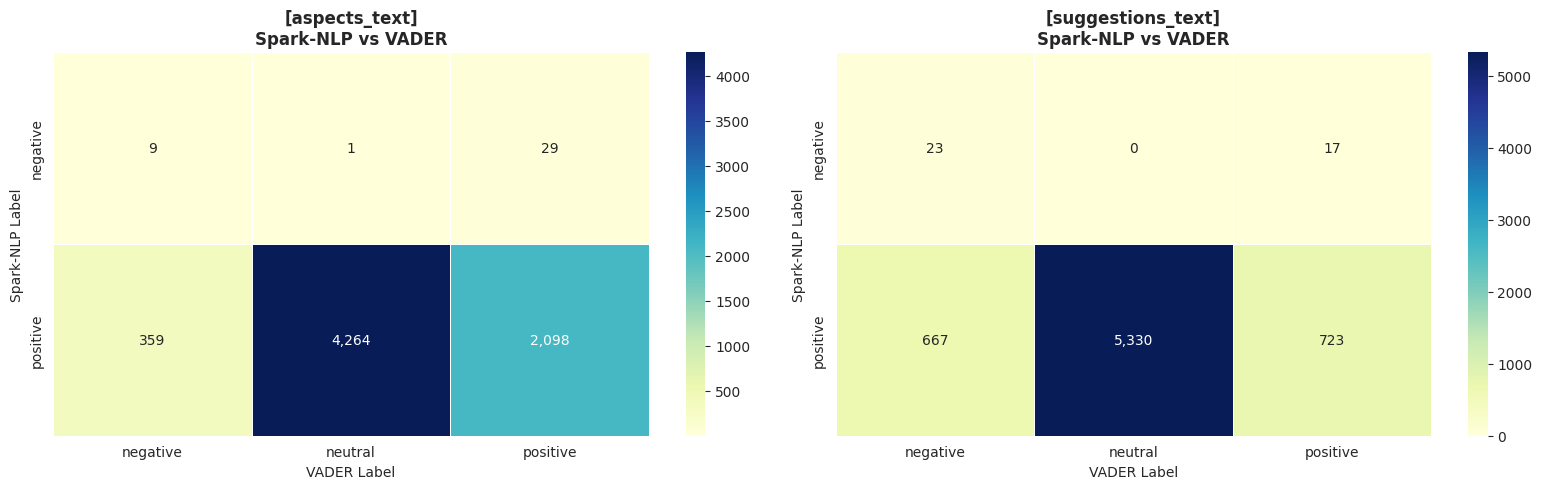

In [19]:
fig, axes = plt.subplots(1, len(TEXT_COLS), figsize=(8 * len(TEXT_COLS), 5))
if len(TEXT_COLS) == 1:
    axes = [axes]

for ax, tc in zip(axes, TEXT_COLS):
    cross = (
        result_df
        .groupBy(f"{tc}_sentiment_label", f"{tc}_vader_label")
        .count().toPandas()
        .rename(columns={
            f"{tc}_sentiment_label": "sentiment_label",
            f"{tc}_vader_label":     "vader_label",
        })
        .pivot(index="sentiment_label", columns="vader_label", values="count")
        .fillna(0).astype(int)
    )
    sns.heatmap(cross, annot=True, fmt=",d", cmap="YlGnBu",
                linewidths=0.5, ax=ax)
    ax.set_title(f"[{tc}]\nSpark-NLP vs VADER", fontsize=12, fontweight="bold")
    ax.set_xlabel("VADER Label"); ax.set_ylabel("Spark-NLP Label")

plt.tight_layout()
plt.show()

### 12.5 VADER Positive / Negative / Neutral Component Scores

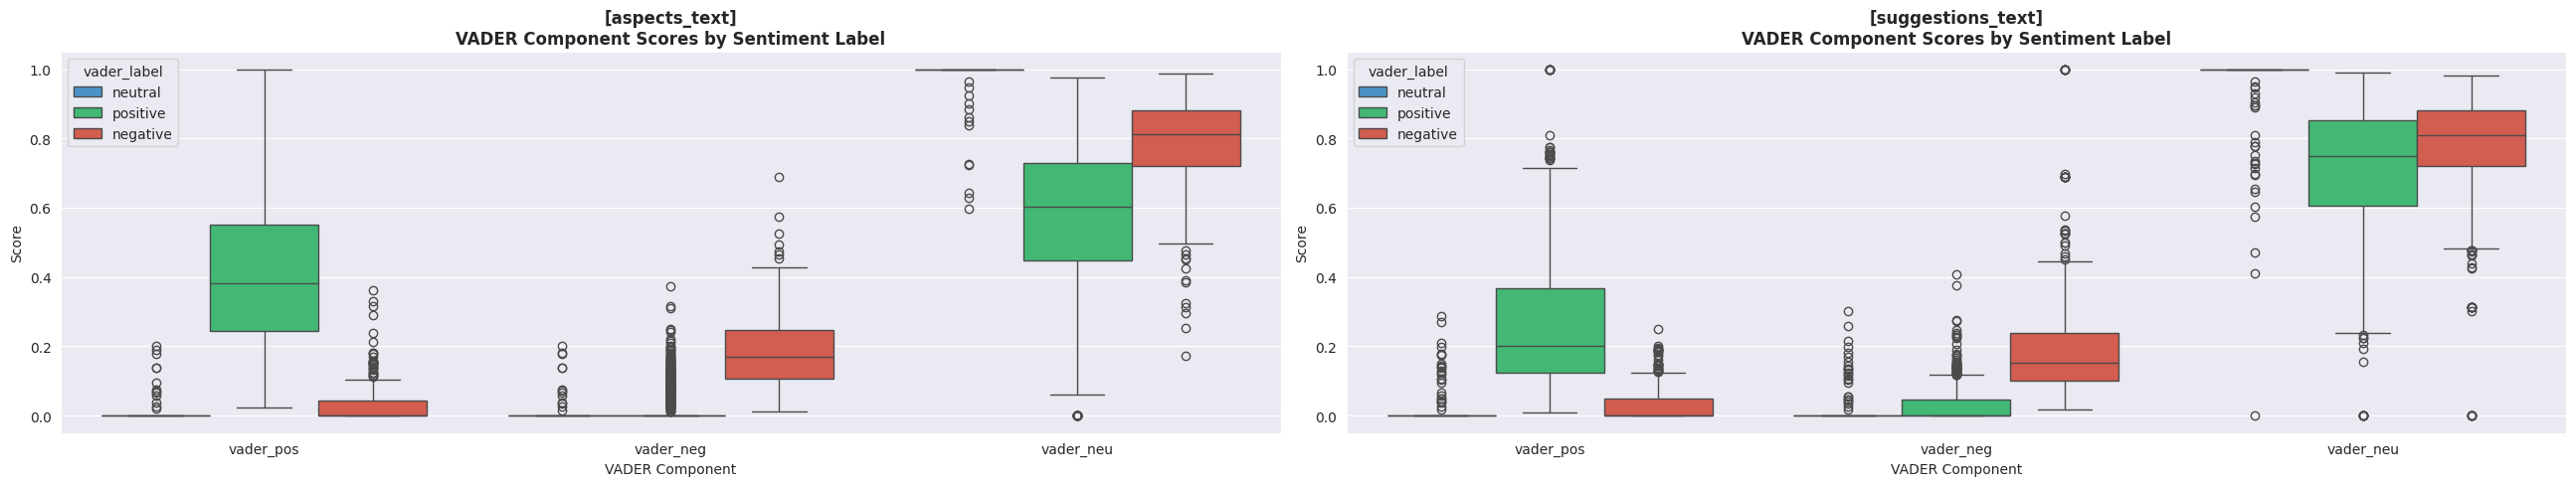

In [20]:
fig, axes = plt.subplots(1, len(TEXT_COLS), figsize=(13 * len(TEXT_COLS), 5))
if len(TEXT_COLS) == 1:
    axes = [axes]

for ax, tc in zip(axes, TEXT_COLS):
    score_pdf = (
        result_df
        .select(f"{tc}_vader_label", f"{tc}_vader_pos",
                f"{tc}_vader_neg",  f"{tc}_vader_neu")
        .limit(5000).toPandas()
        .rename(columns={
            f"{tc}_vader_label": "vader_label",
            f"{tc}_vader_pos":   "vader_pos",
            f"{tc}_vader_neg":   "vader_neg",
            f"{tc}_vader_neu":   "vader_neu",
        })
        .melt(id_vars="vader_label", var_name="component", value_name="score")
    )
    sns.boxplot(
        data=score_pdf, x="component", y="score", hue="vader_label",
        palette={"positive": "#2ecc71", "neutral": "#3498db", "negative": "#e74c3c"},
        ax=ax,
    )
    ax.set_title(f"[{tc}]\nVADER Component Scores by Sentiment Label",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("VADER Component"); ax.set_ylabel("Score")

plt.tight_layout()
plt.show()